In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np
import matplotlib.pyplot as plt

2026-03-17 21:43:18.782900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773783799.041967      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773783799.119504      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773783799.715952      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773783799.716008      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773783799.716012      55 computation_placer.cc:177] computation placer alr

In [4]:
qwen_df = pd.read_csv('/kaggle/input/datasets/ahmedamrabolfadl/scientific-topic-labeling-dataset/qwen_labels.csv')
qwen_df = qwen_df.dropna()
label_cols = ["topic_label", "ver_label", "tax_label", "research_field"]
for col in label_cols:
    qwen_df[col] = qwen_df[col].astype(str).replace(['nan', 'None'], 'unknown')

print("=" * 70)
print("EXPERIMENT 3: Qwen2.5-3B-Instruct with Reinforcement Learning (GRPO)")
print("=" * 70)
print(f"Dataset shape: {qwen_df.shape}")
print(f"Columns: {', '.join(qwen_df.columns.tolist())}\n")
qwen_df.head(10)

EXPERIMENT 3: Qwen2.5-3B-Instruct with Reinforcement Learning (GRPO)
Dataset shape: (139, 6)
Columns: research_field, email, topic_label, topic_words, ver_label, tax_label



,research_field,email,topic_label,topic_words,ver_label,tax_label
0,Image & Video Processing,mohammed.salem@guc.edu.eg,Object Detection and Tracking,"detection, tracking, object, recognition, comp...",Object Detection and Tracking,Object Detection and Tracking
1,Image & Video Processing,mohammed.salem@guc.edu.eg,Image and Video Segmentation,"segmentation, pixels, regions, clustering, bou...",Image Segmentation and Analysis,Image Segmentation and Analysis
2,Image & Video Processing,mohammed.salem@guc.edu.eg,Image Quality Enhancement,"enhancement, filtering, noise, restoration, qu...",Image and Video Enhancement,Image and Video Enhancement
3,Image & Video Processing,mohammed.salem@guc.edu.eg,Video Compression Techniques,"compression, encoding, decoding, storage, band...",Machine Learning and Computer Vision,Image/Video Compression and Encoding
4,Image & Video Processing,mohammed.salem@guc.edu.eg,Image Feature Extraction,"feature, extraction, descriptor, matching, ret...",Image Feature Extraction and Matching,Image Feature Extraction and Matching
5,Image & Video Processing,mohammed.salem@guc.edu.eg,Video Motion Estimation,"motion, estimation, flow, analysis, video",Motion and Video Analysis,Climate Change and Weather Forecasting
6,Image & Video Processing,mohammed.salem@guc.edu.eg,Deep Learning for Vision,"neural, convolutional, learning, deep, networks",Machine Learning for Natural Language Processing,Deep Neural Networks for Image Processing
7,Signal Processing,mohammed.salem@guc.edu.eg,Digital Filter Design,"filter, design, fir, iir, adaptive",Filter Design and Types,Filter Design and Architecture
8,Signal Processing,mohammed.salem@guc.edu.eg,Signal Transformation and Analysis,"transform, fourier, wavelet, spectral, estimation",Signal Transform Methods,Signal Transform and Estimation
9,Signal Processing,mohammed.salem@guc.edu.eg,Noise Reduction and Estimation,"noise, denoising, estimation, kalman, wiener",Signal Denoising and Estimation,Signal Denoising and Estimation


In [5]:
t5_df = pd.read_csv('/kaggle/input/datasets/ahmedamrabolfadl/scientific-topic-labeling-dataset/testing_results_tax_ver_base_large.csv')
t5_df = t5_df.dropna()
label_cols = ["tax_large", "ver_large", "tax_base", "tax_large"]
for col in label_cols:
    t5_df[col] = t5_df[col].astype(str).replace(['nan', 'None'], 'unknown')

print("=" * 70)
print("EXPERIMENT 2: T5-Base & T5-Large with Transfer Learning")
print("=" * 70)
print(f"Dataset shape: {t5_df.shape}")
print(f"Columns: {', '.join(t5_df.columns.tolist())}\n")
t5_df.head(10)

EXPERIMENT 2: T5-Base & T5-Large with Transfer Learning
Dataset shape: (161, 10)
Columns: topic_label, topic_words, tax_large, tax_large_sim, ver_large, ver_large_sim, ver_base, ver_base_sim, tax_base, tax_base_sim



,topic_label,topic_words,tax_large,tax_large_sim,ver_large,ver_large_sim,ver_base,ver_base_sim,tax_base,tax_base_sim
0,Named Entity Recognition,"entity, recognition, linking, extraction, named",Named Entity Recognition,1.0,Named Entity Recognition,1.000000,Entity Recognition and Recognition,0.766280,Entity Recognition Techniques,0.747225
1,Cloud and Edge Computing,"cloud, edge, computing, decentralized, processing",Cloud and Edge Computing,1.0,Cloud Edge Computing,0.903332,Cloud Computing and Edge Computing,0.966223,Cloud Computing and Edge Computing,0.966223
2,Natural Language Processing,"language, natural, processing, translation, se...",Natural Language Processing,1.0,Natural Language Processing,1.000000,Natural Language Processing,1.000000,Natural Language Processing,1.000000
3,Natural Language Processing,"natural, language, text, sentiment, nlp",Natural Language Processing,1.0,Natural Language Processing,1.000000,Natural Language Processing,1.000000,Natural Language Processing,1.000000
4,Real-Time Stream Processing,"stream, processing, real-time, kafka, flink",Real-Time Stream Processing,1.0,Real-Time Stream Processing,1.000000,Real-Time Communication,0.610578,Real-Time Stream Processing,1.000000
5,Time Series Forecasting,"time, series, forecasting, trending, seasonal",Time Series Forecasting,1.0,Time Series Forecasting,1.000000,Time Series Forecasting,1.000000,Time Series Forecasting,1.000000
6,Logic Synthesis and Optimization,"synthesis, logic, rtl, timing, optimization",Logic Synthesis and Optimization,1.0,Logic-Based Synthesis,0.846317,Synthesis and Optimization,0.804243,Synthesis and Logic,0.794267
7,Density Functional Theory,"density, functional, theory, electronic, struc...",Density Functional Theory,1.0,Electronic Structure Theory,0.521604,Electronic Structure and Density,0.651343,Electronic Structure Theory,0.521604
8,Integrated Circuit Design,"integrated, circuit, design, layout, verification",Integrated Circuit Design,1.0,Integrated Circuit Design,1.000000,Integrated Circuit Design,1.000000,Integrated Circuit Design,1.000000
9,Image and Video Processing,"image, video, processing, enhancement, segment...",Image and Video Processing,1.0,Image Processing and Enhancement,0.732127,Image Processing and Segmentation,0.708048,Image Processing Techniques,0.737310


In [6]:
flan_df = pd.read_csv('/kaggle/input/datasets/ahmedamrabolfadl/scientific-topic-labeling-dataset/flan_labels.csv')
flan_df = flan_df.dropna()
label_cols = ["full_base_label", "lora_base_label", "lora_large_label"]
for col in label_cols:
    flan_df[col] = flan_df[col].astype(str).replace(['nan', 'None'], 'unknown')

print("=" * 70)
print("EXPERIMENT 4 & 5: FLAN-T5 with Curriculum Learning")
print("=" * 70)
print(f"Dataset shape: {flan_df.shape}")
print(f"Columns: {', '.join(flan_df.columns.tolist())}\n")
flan_df.head(10)

EXPERIMENT 4 & 5: FLAN-T5 with Curriculum Learning
Dataset shape: (140, 8)
Columns: Unnamed: 0, research_field, email, topic_label, topic_words, full_base_label, lora_base_label, lora_large_label



,Unnamed: 0,research_field,email,topic_label,topic_words,full_base_label,lora_base_label,lora_large_label
0,0,Image & Video Processing,mohammed.salem@guc.edu.eg,Object Detection and Tracking,"detection, tracking, object, recognition, comp...",Object Detection and Tracking,Image and Video Processing,computer-aided object recognition
1,1,Image & Video Processing,mohammed.salem@guc.edu.eg,Image and Video Segmentation,"segmentation, pixels, regions, clustering, bou...",Image Segmentation Techniques,Image and Video Processing,segmentation
2,2,Image & Video Processing,mohammed.salem@guc.edu.eg,Image Quality Enhancement,"enhancement, filtering, noise, restoration, qu...",Video Quality Enhancement,Image and Video Processing,enhancement of image quality
3,3,Image & Video Processing,mohammed.salem@guc.edu.eg,Video Compression Techniques,"compression, encoding, decoding, storage, band...",Video Compression and Encoding,Image and Video Processing,encoding
4,4,Image & Video Processing,mohammed.salem@guc.edu.eg,Image Feature Extraction,"feature, extraction, descriptor, matching, ret...",Feature Extraction Techniques,Image & Video Processing,feature extraction and retrieval
5,5,Image & Video Processing,mohammed.salem@guc.edu.eg,Video Motion Estimation,"motion, estimation, flow, analysis, video",Motion Estimation and Analysis,Image and Video Processing,motion estimation in video
6,6,Image & Video Processing,mohammed.salem@guc.edu.eg,Deep Learning for Vision,"neural, convolutional, learning, deep, networks",Neural Image Processing,Image and Video Processing,convolutional neural network
7,7,Signal Processing,mohammed.salem@guc.edu.eg,Digital Filter Design,"filter, design, fir, iir, adaptive",Adaptive Signal Filtering,Signal Processing,adaptive filtering iir
8,8,Signal Processing,mohammed.salem@guc.edu.eg,Signal Transformation and Analysis,"transform, fourier, wavelet, spectral, estimation",Transform and Fourier Methods,Signal Processing,spectral wavelet estimator
9,9,Signal Processing,mohammed.salem@guc.edu.eg,Noise Reduction and Estimation,"noise, denoising, estimation, kalman, wiener",Noise Estimation Methods,Signal Processing,denoising with kalman filter


In [7]:
gemini_df = pd.read_csv('/kaggle/input/datasets/ahmedamrabolfadl/scientific-topic-labeling-dataset/test_gemini_labels.csv')
gemini_df = gemini_df.dropna()
gemini_df = gemini_df.rename(columns={'response': 'gemini_label'})
label_cols = ["gemini_label"]
for col in label_cols:
    gemini_df[col] = gemini_df[col].astype(str).replace(['nan', 'None'], 'unknown')

print("=" * 70)
print("BENCHMARK: Gemini Pro Labels (Experiment 0)")
print("=" * 70)
print(f"Dataset shape: {gemini_df.shape}")
print(f"Columns: {', '.join(gemini_df.columns.tolist())}\n")
gemini_df.head(10)

BENCHMARK: Gemini Pro Labels (Experiment 0)
Dataset shape: (140, 3)
Columns: topic_words, prompt, gemini_label



,topic_words,prompt,gemini_label
0,"detection, tracking, object, recognition, comp...",System Prompt: You are an expert at analyzing ...,Object Detection and Tracking
1,"segmentation, pixels, regions, clustering, bou...",System Prompt: You are an expert at analyzing ...,Image Segmentation and Clustering
2,"enhancement, filtering, noise, restoration, qu...",System Prompt: You are an expert at analyzing ...,Image Restoration and Enhancement
3,"compression, encoding, decoding, storage, band...",System Prompt: You are an expert at analyzing ...,Image and Video Compression
4,"feature, extraction, descriptor, matching, ret...",System Prompt: You are an expert at analyzing ...,Feature Extraction and Retrieval
5,"motion, estimation, flow, analysis, video",System Prompt: You are an expert at analyzing ...,Motion Estimation and Analysis
6,"neural, convolutional, learning, deep, networks",System Prompt: You are an expert at analyzing ...,Deep Learning and Convolutional Neural Networks
7,"filter, design, fir, iir, adaptive",System Prompt: You are an expert at analyzing ...,Digital Filter Design
8,"transform, fourier, wavelet, spectral, estimation",System Prompt: You are an expert at analyzing ...,Spectral Analysis and Transforms
9,"noise, denoising, estimation, kalman, wiener",System Prompt: You are an expert at analyzing ...,Noise Estimation and Denoising


In [9]:
# 1. Define columns for the existing T5 merge and the new Gemini merge
cols_t5 = ["topic_words", "ver_base", "ver_large", "tax_base", "tax_large"]
cols_flan = ["topic_words", "full_base_label", "lora_base_label", "lora_large_label"]
cols_gemini = ["topic_words", "gemini_label"] 

# 2. Perform chained inner merge
df = (
    qwen_df
    .merge(t5_df[cols_t5], on='topic_words', how='inner')
    .merge(flan_df[cols_flan], on='topic_words', how='inner')
    .merge(gemini_df[cols_gemini], on='topic_words', how='inner')
)

# Rename columns to align with experiment naming conventions in the Overview
rename_mapping = {
    # Experiment 3: RL Fine-tuning (Qwen2.5-3B-Instruct with GRPO)
    'tax_label': 'qwen_rl_taxonomy',
    'ver_label': 'qwen_rl_verified',
    
    # Experiment 2: Transfer Learning (T5-base and T5-large with frozen encoder)
    'ver_base': 't5_base_verified',
    'ver_large': 't5_large_verified',
    'tax_base': 't5_base_taxonomy',
    'tax_large': 't5_large_taxonomy',
    
    # Experiment 4: Full Fine-tuning (FLAN-T5-Base with curriculum learning)
    'full_base_label': 'flan_t5_base_full_cl',
    
    # Experiment 5: LoRA Fine-tuning (FLAN-T5-Base/Large with curriculum learning)
    'lora_base_label': 'flan_t5_base_lora_cl',
    'lora_large_label': 'flan_t5_large_lora_cl',
    
    # Benchmark: Gemini Pro (from Experiment 0)
    'gemini_label': 'gemini_pro_benchmark',
}

df = df.rename(columns=rename_mapping)

print("=" * 80)
print("DATA CONSOLIDATION AND COLUMN STANDARDIZATION")
print("=" * 80)
print(f"Merged dataset shape: {df.shape[0]} samples × {df.shape[1]} columns\n")

print("Model Outputs Included:")
print("-" * 80)
print("Experiment 2 (Transfer Learning - T5):        4 models")
print("  • t5_base_verified, t5_large_verified")
print("  • t5_base_taxonomy, t5_large_taxonomy")
print("\nExperiment 3 (Reinforcement Learning - Qwen): 2 models")
print("  • qwen_rl_verified, qwen_rl_taxonomy")
print("\nExperiment 4 (Full Fine-tuning - FLAN-T5):   1 model")
print("  • flan_t5_base_full_cl")
print("\nExperiment 5 (LoRA Fine-tuning - FLAN-T5):   2 models")
print("  • flan_t5_base_lora_cl, flan_t5_large_lora_cl")
print("\nBenchmark (Gemini Pro - LLM):                  1 model")
print("  • gemini_pro_benchmark")
print("-" * 80)
print(f"\nTotal models for comparison: {len([c for c in df.columns if c not in ['topic_words', 'topic_label', 'research_field']])}\n")
df.head(10)

DATA CONSOLIDATION AND COLUMN STANDARDIZATION
Merged dataset shape: 139 samples × 14 columns

Model Outputs Included:
--------------------------------------------------------------------------------
Experiment 2 (Transfer Learning - T5):        4 models
  • t5_base_verified, t5_large_verified
  • t5_base_taxonomy, t5_large_taxonomy

Experiment 3 (Reinforcement Learning - Qwen): 2 models
  • qwen_rl_verified, qwen_rl_taxonomy

Experiment 4 (Full Fine-tuning - FLAN-T5):   1 model
  • flan_t5_base_full_cl

Experiment 5 (LoRA Fine-tuning - FLAN-T5):   2 models
  • flan_t5_base_lora_cl, flan_t5_large_lora_cl

Benchmark (Gemini Pro - LLM):                  1 model
  • gemini_pro_benchmark
--------------------------------------------------------------------------------

Total models for comparison: 11



,research_field,email,topic_label,topic_words,qwen_rl_verified,qwen_rl_taxonomy,t5_base_verified,t5_large_verified,t5_base_taxonomy,t5_large_taxonomy,flan_t5_base_full_cl,flan_t5_base_lora_cl,flan_t5_large_lora_cl,gemini_pro_benchmark
0,Image & Video Processing,mohammed.salem@guc.edu.eg,Object Detection and Tracking,"detection, tracking, object, recognition, comp...",Object Detection and Tracking,Object Detection and Tracking,Object Tracking and Recognition,Object Recognition and Tracking,Object Recognition Techniques,Computer Vision and Object Recognition,Object Detection and Tracking,Image and Video Processing,computer-aided object recognition,Object Detection and Tracking
1,Image & Video Processing,mohammed.salem@guc.edu.eg,Image and Video Segmentation,"segmentation, pixels, regions, clustering, bou...",Image Segmentation and Analysis,Image Segmentation and Analysis,Segmentation and Clustering,Image Segmentation and Clustering,Pixel Segmentation Techniques,Image Segmentation and Clustering,Image Segmentation Techniques,Image and Video Processing,segmentation,Image Segmentation and Clustering
2,Image & Video Processing,mohammed.salem@guc.edu.eg,Image Quality Enhancement,"enhancement, filtering, noise, restoration, qu...",Image and Video Enhancement,Image and Video Enhancement,Noise Reduction and Enhancement,Noise Reduction Techniques,Noise Restoration Techniques,Audio Enhancement and Restoration,Video Quality Enhancement,Image and Video Processing,enhancement of image quality,Image Restoration and Enhancement
3,Image & Video Processing,mohammed.salem@guc.edu.eg,Video Compression Techniques,"compression, encoding, decoding, storage, band...",Machine Learning and Computer Vision,Image/Video Compression and Encoding,Compression and Decoding,Data Compression Techniques,Data Compression and Decoding,Video Compression and Storage,Video Compression and Encoding,Image and Video Processing,encoding,Image and Video Compression
4,Image & Video Processing,mohammed.salem@guc.edu.eg,Image Feature Extraction,"feature, extraction, descriptor, matching, ret...",Image Feature Extraction and Matching,Image Feature Extraction and Matching,Feature Extraction and Retrieval,Feature Extraction and Matching,Descriptor Analysis Techniques,Feature Extraction and Matching,Feature Extraction Techniques,Image & Video Processing,feature extraction and retrieval,Feature Extraction and Retrieval
5,Image & Video Processing,mohammed.salem@guc.edu.eg,Video Motion Estimation,"motion, estimation, flow, analysis, video",Motion and Video Analysis,Climate Change and Weather Forecasting,Motion Estimation Techniques,Motion Estimation Techniques,Motion Estimation Techniques,Video Motion Analysis,Motion Estimation and Analysis,Image and Video Processing,motion estimation in video,Motion Estimation and Analysis
6,Image & Video Processing,mohammed.salem@guc.edu.eg,Deep Learning for Vision,"neural, convolutional, learning, deep, networks",Machine Learning for Natural Language Processing,Deep Neural Networks for Image Processing,Deep Neural Networks,Deep Neural Networks,Deep Learning Techniques,Deep Neural Networks,Neural Image Processing,Image and Video Processing,convolutional neural network,Deep Learning and Convolutional Neural Networks
7,Signal Processing,mohammed.salem@guc.edu.eg,Digital Filter Design,"filter, design, fir, iir, adaptive",Filter Design and Types,Filter Design and Architecture,Intelligent Filter Design,Adaptive Filter Design,Advanced Filter Design,Adaptive Filter Design,Adaptive Signal Filtering,Signal Processing,adaptive filtering iir,Digital Filter Design
8,Signal Processing,mohammed.salem@guc.edu.eg,Signal Transformation and Analysis,"transform, fourier, wavelet, spectral, estimation",Signal Transform Methods,Signal Transform and Estimation,Fourier Transform Methods,Fourier Transform Estimation,Fourier Methods and Estimation,Fourier Transform Methods,Transform and Fourier Methods,Signal Processing,spectral wavelet estimator,Spectral Analysis and Tra

In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')

def calculate_column_similarities(df, true_col, generated_cols):
    results = {}
    
    true_embeddings = model.encode(df[true_col].tolist(), convert_to_tensor=True)
    
    for gen_col in generated_cols:
        gen_embeddings = model.encode(df[gen_col].tolist(), convert_to_tensor=True)
        
        cosine_scores = util.cos_sim(true_embeddings, gen_embeddings)
        row_wise_similarities = cosine_scores.diagonal()
        results[gen_col] = row_wise_similarities.cpu().numpy()
        
    return results

generated_models = ['qwen_rl_taxonomy', 'qwen_rl_verified', 't5_base_verified', 't5_large_verified', 't5_base_taxonomy', 't5_large_taxonomy', 'flan_t5_base_full_cl', 'flan_t5_base_lora_cl', 'flan_t5_large_lora_cl', 'gemini_pro_benchmark']

similarities = calculate_column_similarities(df, 'topic_label', generated_models)

for gen_col, scores in similarities.items():
    df[f"{gen_col}_score"] = scores

# 3. Compute and display summary statistics
print("=" * 100)
print("SEMANTIC SIMILARITY ANALYSIS: Generated Labels vs. Ground Truth")
print("=" * 100)
print("\nEmbedding Model: all-MiniLM-L6-v2 (Sentence Transformers)")
print("Metric: Cosine Similarity (row-wise between generated and ground truth embeddings)\n")

stats_data = []
for gen_col in generated_models:
    scores = df[f"{gen_col}_score"].values
    stats_data.append({
        'Model': gen_col,
        'Mean': f"{scores.mean():.4f}",
        'Median': f"{np.median(scores):.4f}",
        'Std Dev': f"{scores.std():.4f}",
        'Min': f"{scores.min():.4f}",
        'Max': f"{scores.max():.4f}",
        '% ≥ 0.80': f"{(scores >= 0.80).mean() * 100:.1f}%",
        '% ≥ 0.90': f"{(scores >= 0.90).mean() * 100:.1f}%",
    })

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
print("\n" + "=" * 100)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SEMANTIC SIMILARITY ANALYSIS: Generated Labels vs. Ground Truth

Embedding Model: all-MiniLM-L6-v2 (Sentence Transformers)
Metric: Cosine Similarity (row-wise between generated and ground truth embeddings)

                Model   Mean Median Std Dev     Min    Max % ≥ 0.80 % ≥ 0.90
     qwen_rl_taxonomy 0.6114 0.6702  0.2536  0.0272 1.0000    25.9%    11.5%
     qwen_rl_verified 0.6146 0.6701  0.2551 -0.0199 1.0000    29.5%     9.4%
     t5_base_verified 0.6524 0.6436  0.2051  0.1581 1.0000    28.8%    12.9%
    t5_large_verified 0.6601 0.6597  0.2064  0.0790 1.0000    30.2%    13.7%
     t5_base_taxonomy 0.6537 0.6547  0.2092  0.1365 1.0000    27.3%    12.9%
    t5_large_taxonomy 0.6683 0.6532  0.2001  0.0060 1.0000    30.9%    12.9%
 flan_t5_base_full_cl 0.7128 0.7262  0.1861  0.0683 1.0000    31.7%    15.8%
 flan_t5_base_lora_cl 0.4871 0.5058  0.1721  0.0239 0.9303     2.9%     0.7%
flan_t5_large_lora_cl 0.5796 0.5792  0.2110  0.0273 1.0000    14.4%     7.9%
 gemini_pro_benchmark 0


FIGURE 1: SIMILARITY SCORE DISTRIBUTION COMPARISON


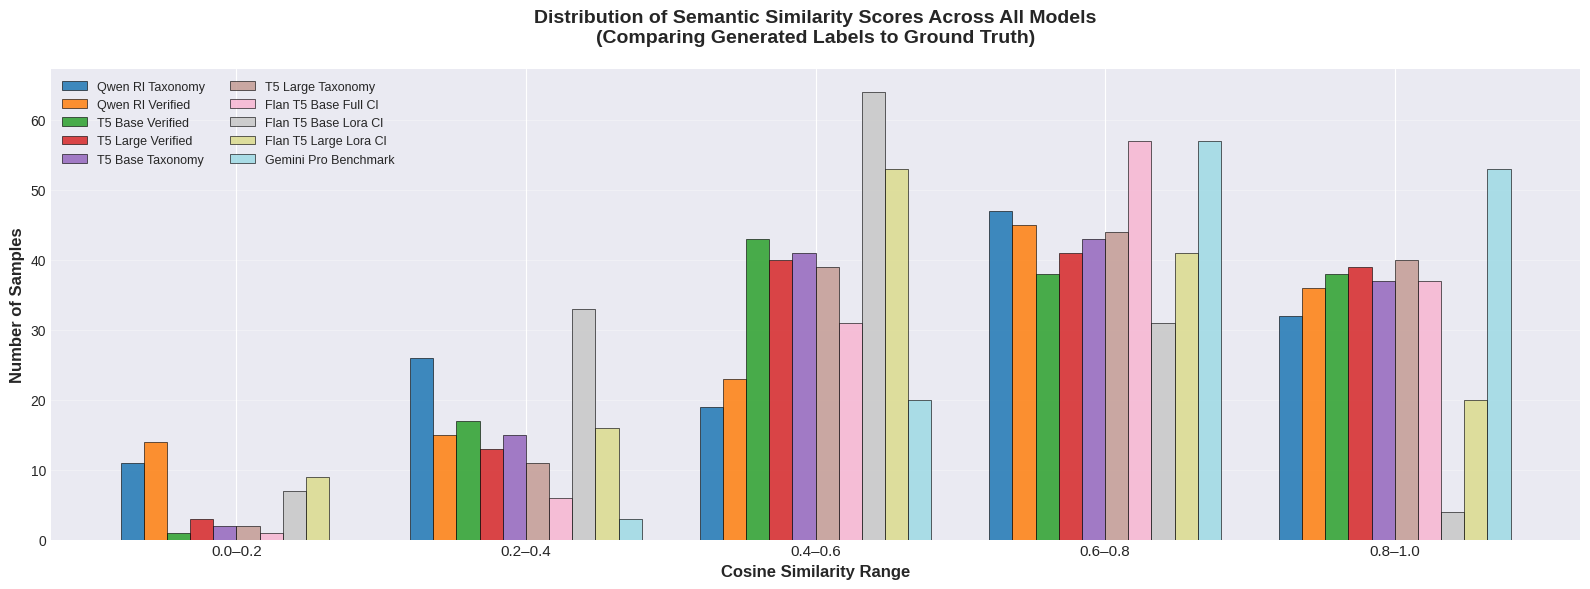


Figure saved as: figure1_similarity_distribution.png


In [11]:
print("\n" + "=" * 100)
print("FIGURE 1: SIMILARITY SCORE DISTRIBUTION COMPARISON")
print("=" * 100)

bins = np.arange(0, 1.01, 0.2)
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]
x = np.arange(len(labels))

# Create figure with professional styling
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(16, 6))

width = 0.8 / len(similarities)
colors = plt.cm.tab20(np.linspace(0, 1, len(similarities)))

for i, (col, values) in enumerate(similarities.items()):
    counts, _ = np.histogram(values, bins=bins)
    offset = (i - (len(similarities) - 1) / 2) * width
    
    # Format label for legend
    label_name = col.replace('_', ' ').title()
    ax.bar(x + offset, counts, width, label=label_name, color=colors[i], alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Cosine Similarity Range', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Semantic Similarity Scores Across All Models\n(Comparing Generated Labels to Ground Truth)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('figure1_similarity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as: figure1_similarity_distribution.png")

In [12]:
label_cols = [
    'qwen_rl_taxonomy_score', 'qwen_rl_verified_score', 't5_base_verified_score', 
    't5_large_verified_score', 't5_base_taxonomy_score', 't5_large_taxonomy_score', 'flan_t5_base_full_cl_score', 'flan_t5_base_lora_cl_score', 'flan_t5_large_lora_cl_score'
]

# Calculate the signed difference for each column
for col in label_cols:
    # Creating a new column name by replacing '_score' with '_diff'
    new_col_name = col.replace('_score', '_diff')
    df[new_col_name] = df[col] - df['gemini_pro_benchmark_score']

# Compute difference statistics
print("\n" + "=" * 100)
print("PERFORMANCE DIFFERENTIAL ANALYSIS: Model vs. Gemini Pro Benchmark")
print("=" * 100)
print("\nPositive values indicate performance above Gemini Pro (higher cosine similarity).")
print("Negative values indicate performance below Gemini Pro (lower cosine similarity).\n")

diff_stats_data = []
for col in label_cols:
    diff_col = col.replace('_score', '_diff')
    diffs = df[diff_col].values
    diff_stats_data.append({
        'Model': col.replace('_score', ''),
        'Mean Δ': f"{diffs.mean():+.4f}",
        'Median Δ': f"{np.median(diffs):+.4f}",
        'Std Dev': f"{diffs.std():.4f}",
        'Min Δ': f"{diffs.min():+.4f}",
        'Max Δ': f"{diffs.max():+.4f}",
        '% Better': f"{(diffs > 0).mean() * 100:.1f}%",
    })

diff_stats_df = pd.DataFrame(diff_stats_data)
print(diff_stats_df.to_string(index=False))
print("\n" + "=" * 100)


PERFORMANCE DIFFERENTIAL ANALYSIS: Model vs. Gemini Pro Benchmark

Positive values indicate performance above Gemini Pro (higher cosine similarity).
Negative values indicate performance below Gemini Pro (lower cosine similarity).

                Model  Mean Δ Median Δ Std Dev   Min Δ   Max Δ % Better
     qwen_rl_taxonomy -0.1442  -0.0592  0.2289 -0.7740 +0.2195    30.2%
     qwen_rl_verified -0.1410  -0.0436  0.2552 -0.9340 +0.2952    32.4%
     t5_base_verified -0.1031  -0.0790  0.1958 -0.6107 +0.3344    33.1%
    t5_large_verified -0.0954  -0.0522  0.1858 -0.6643 +0.3344    30.9%
     t5_base_taxonomy -0.1019  -0.0682  0.1957 -0.8566 +0.3344    32.4%
    t5_large_taxonomy -0.0872  -0.0288  0.1872 -0.6614 +0.3708    36.0%
 flan_t5_base_full_cl -0.0428  -0.0045  0.1790 -0.5884 +0.4549    39.6%
 flan_t5_base_lora_cl -0.2685  -0.2514  0.2368 -0.8891 +0.2309    12.9%
flan_t5_large_lora_cl -0.1760  -0.1618  0.2371 -0.8143 +0.3284    24.5%




FIGURE 2: CUMULATIVE PERFORMANCE ADVANTAGE ANALYSIS

Area Under Curve (AUC) represents cumulative performance differential vs. Gemini Pro.
Positive AUC: Model outperforms Gemini Pro overall. Negative AUC: Model underperforms.



/tmp/ipykernel_55/4175031095.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(sorted_values, x)


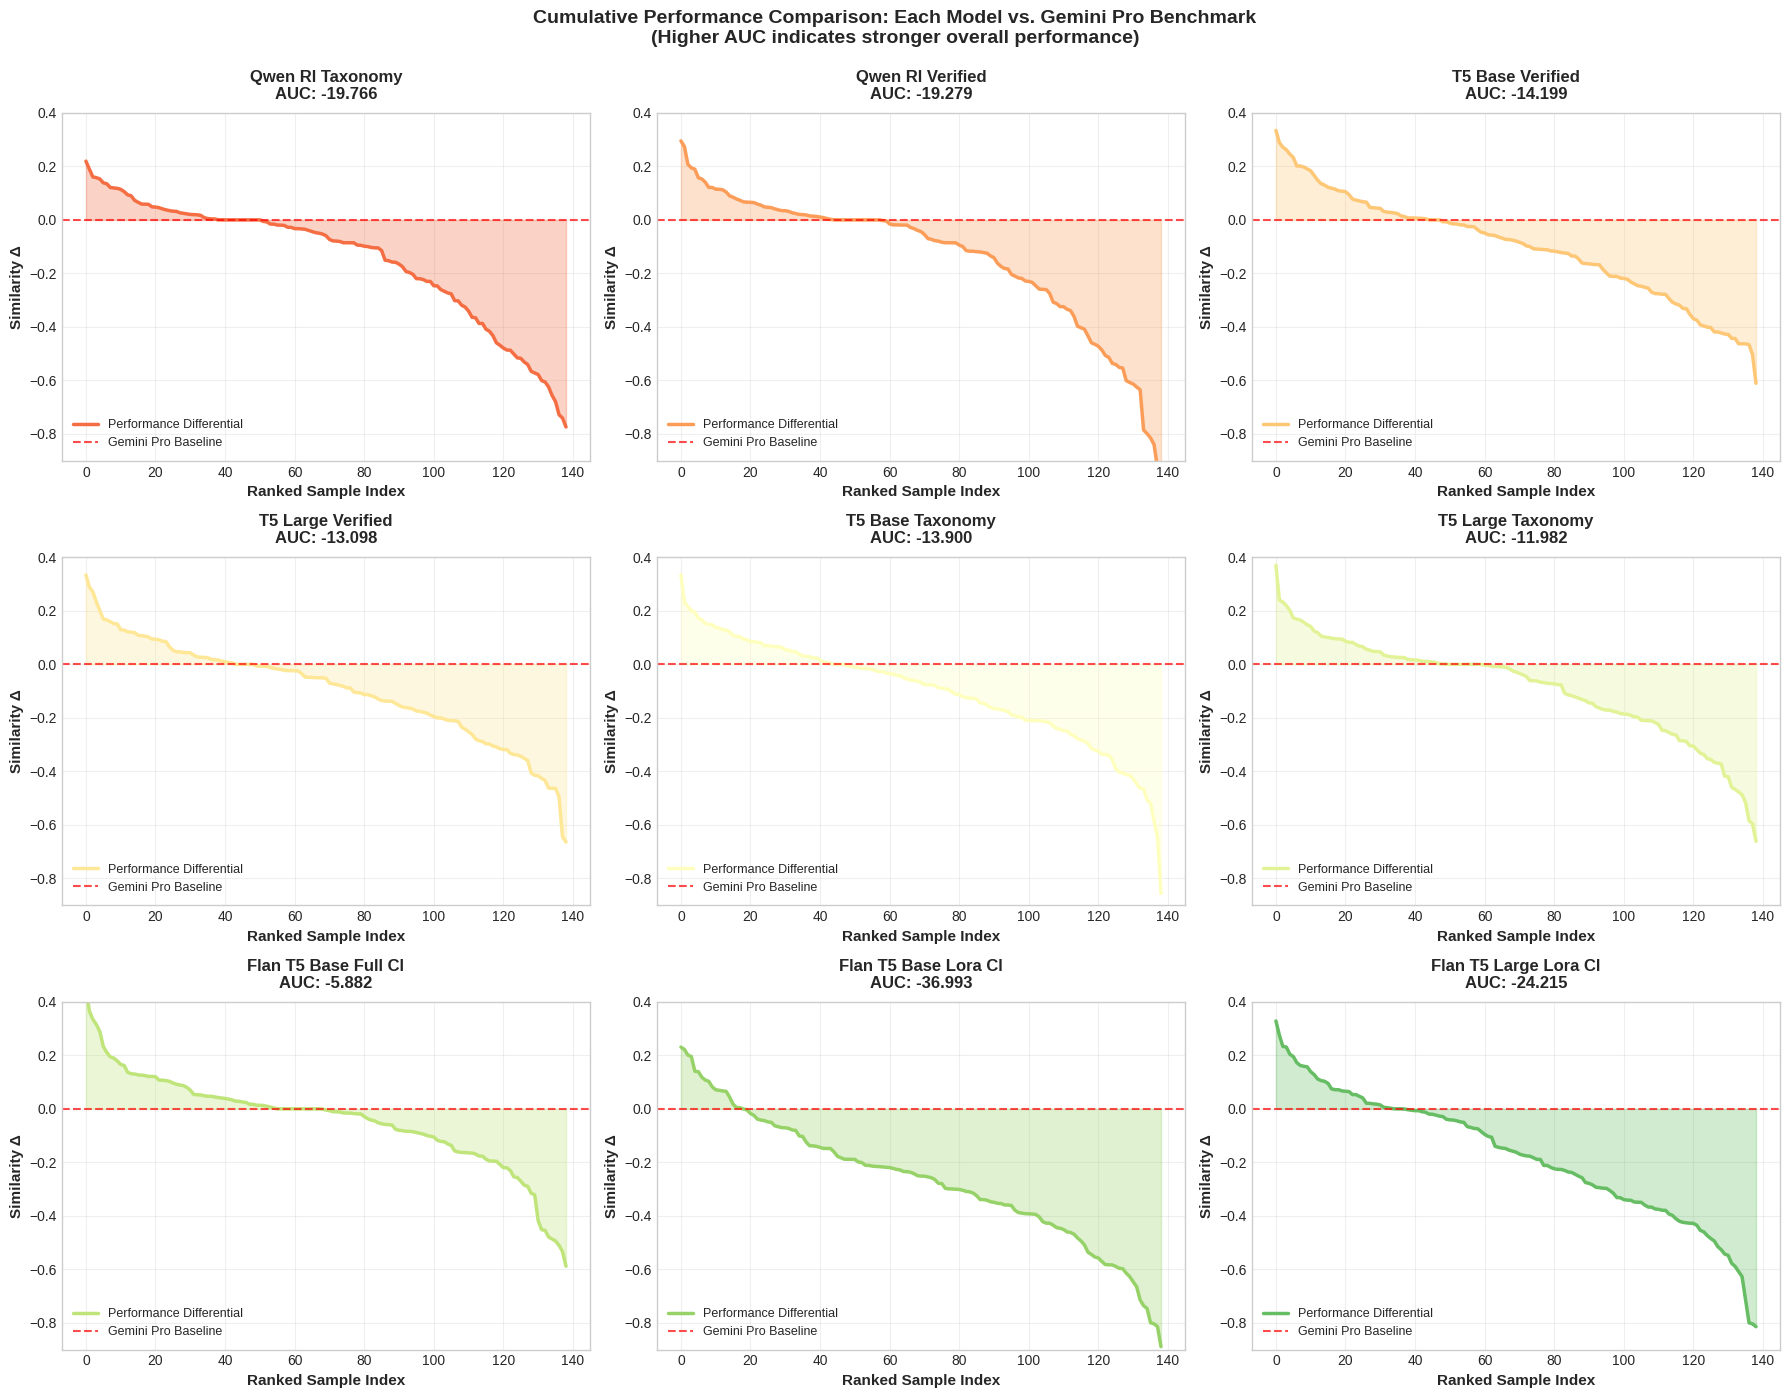


Figure saved as: figure2_auc_analysis.png

TABLE 1: CUMULATIVE PERFORMANCE RANKING (AUC Scores)

 Rank                 Model AUC Score Relative Performance
    1  flan_t5_base_full_cl   -5.8823              ↓ Worse
    2     t5_large_taxonomy  -11.9819              ↓ Worse
    3     t5_large_verified  -13.0985              ↓ Worse
    4      t5_base_taxonomy  -13.8999              ↓ Worse
    5      t5_base_verified  -14.1992              ↓ Worse
    6      qwen_rl_verified  -19.2787              ↓ Worse
    7      qwen_rl_taxonomy  -19.7663              ↓ Worse
    8 flan_t5_large_lora_cl  -24.2153              ↓ Worse
    9  flan_t5_base_lora_cl  -36.9931              ↓ Worse



In [13]:
diff_cols = [
    'qwen_rl_taxonomy_diff', 'qwen_rl_verified_diff', 't5_base_verified_diff', 
    't5_large_verified_diff', 't5_base_taxonomy_diff', 't5_large_taxonomy_diff', 'flan_t5_base_full_cl_diff', 'flan_t5_base_lora_cl_diff', 'flan_t5_large_lora_cl_diff'
]

print("\n" + "=" * 100)
print("FIGURE 2: CUMULATIVE PERFORMANCE ADVANTAGE ANALYSIS")
print("=" * 100)
print("\nArea Under Curve (AUC) represents cumulative performance differential vs. Gemini Pro.")
print("Positive AUC: Model outperforms Gemini Pro overall. Negative AUC: Model underperforms.\n")

# Create figure with professional styling
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

auc_results = {}
colors_auc = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(diff_cols)))

for i, col in enumerate(diff_cols):
    # 1. Sort the column descendingly
    sorted_values = df[col].sort_values(ascending=False).values
    x = np.arange(len(sorted_values))
    
    # 2. Calculate Area Under Graph (Integral)
    auc = np.trapz(sorted_values, x)
    auc_results[col] = auc
    
    # 3. Plotting
    color = colors_auc[i]
    axes[i].plot(x, sorted_values, color=color, lw=2.5, label='Performance Differential')
    axes[i].fill_between(x, sorted_values, alpha=0.3, color=color)
    
    # 4. Add a reference line at zero
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Gemini Pro Baseline')

    axes[i].set_ylim(-0.9, 0.4)
    axes[i].set_xlabel('Ranked Sample Index', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Similarity Δ', fontsize=11, fontweight='bold')
    
    model_name = col.replace('_diff', '').replace('_', ' ').title()
    axes[i].set_title(f'{model_name}\nAUC: {auc:+.3f}', fontsize=12, fontweight='bold', pad=10)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.suptitle('Cumulative Performance Comparison: Each Model vs. Gemini Pro Benchmark\n(Higher AUC indicates stronger overall performance)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('figure2_auc_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as: figure2_auc_analysis.png")

# Print the final rankings as a formatted table
print("\n" + "=" * 100)
print("TABLE 1: CUMULATIVE PERFORMANCE RANKING (AUC Scores)")
print("=" * 100 + "\n")

ranking_data = []
for rank, (col, val) in enumerate(sorted(auc_results.items(), key=lambda x: x[1], reverse=True), 1):
    ranking_data.append({
        'Rank': rank,
        'Model': col.replace('_diff', ''),
        'AUC Score': f"{val:+.4f}",
        'Relative Performance': '↑ Better' if val > 0 else '↓ Worse'
    })

ranking_df = pd.DataFrame(ranking_data)
print(ranking_df.to_string(index=False))
print("\n" + "=" * 100)